# 06 - Imbalance & Extreme Distribution Handling
**Metro Traffic Flow Prediction - Target Skewness, Robust Loss & Congestion Binning**

In regression tasks, imbalance manifests as **extreme tail values** and **skewed target distributions** (e.g. rare peak congestion events). This notebook explores target transformations, robust loss modeling, and congestion-level class distribution analysis.

---
### 1. Target Skewness & Tail Distribution Audit

Target Skewness: 0.6353
Target Kurtosis: -0.4646


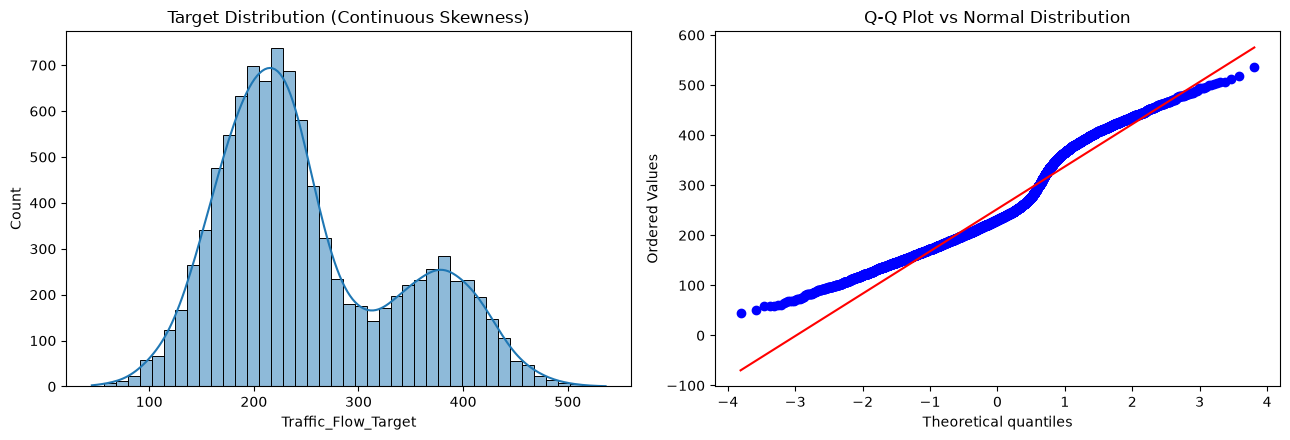

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import scipy.stats as stats

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_path = root / "data" / "raw" / "metro_traffic_dataset_10000.csv"
if not data_path.exists():
    data_path = root / "01_Dataset" / "cleaned_dataset.csv"

df = pd.read_csv(data_path)
target = df["Traffic_Flow_Target"]

print(f"Target Skewness: {target.skew():.4f}")
print(f"Target Kurtosis: {target.kurt():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(target, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Target Distribution (Continuous Skewness)")

stats.probplot(target, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot vs Normal Distribution")
plt.tight_layout()
plt.show()

---
### 2. Target Transformation & Robust Loss Comparison
We compare:
1. Standard Linear Regression (raw target)
2. Log-Transformed Regression ($y_{log} = \log(1 + y)$)
3. Power-Transformed Regression (Yeo-Johnson)
4. Huber Regressor (Robust loss downweighting extreme congestion outliers)

In [2]:
X = df.drop(columns=["Timestamp", "Traffic_Flow_Target"])
y = df["Traffic_Flow_Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Model 1: Standard
lr = LinearRegression().fit(X_train_s, y_train)
p_std = lr.predict(X_test_s)

# Model 2: Log Transform
y_train_log = np.log1p(y_train)
lr_log = LinearRegression().fit(X_train_s, y_train_log)
p_log = np.expm1(lr_log.predict(X_test_s))

# Model 3: Huber Regressor (Robust to tail outliers)
huber = HuberRegressor(max_iter=1000).fit(X_train_s, y_train)
p_huber = huber.predict(X_test_s)

imb_results = pd.DataFrame([
    {"Approach": "Standard Linear Regression", "MAE": mean_absolute_error(y_test, p_std), "RMSE": root_mean_squared_error(y_test, p_std), "R2": r2_score(y_test, p_std)},
    {"Approach": "Log-Transformed Target", "MAE": mean_absolute_error(y_test, p_log), "RMSE": root_mean_squared_error(y_test, p_log), "R2": r2_score(y_test, p_log)},
    {"Approach": "Huber Robust Regressor", "MAE": mean_absolute_error(y_test, p_huber), "RMSE": root_mean_squared_error(y_test, p_huber), "R2": r2_score(y_test, p_huber)}
])
display(imb_results.round(3))

,Approach,MAE,RMSE,R2
0,Standard Linear Regression,20.402,25.398,0.916
1,Log-Transformed Target,21.467,26.685,0.907
2,Huber Robust Regressor,20.400,25.404,0.916


---
### 3. Traffic Congestion Level Discretization (Classification Perspective)
To address discrete class imbalance, we categorize continuous traffic flow into 4 Transit Service Levels:
- **Low Flow:** `< 150`
- **Moderate Flow:** `150 - 250`
- **High Demand:** `250 - 350`
- **Severe Congestion:** `> 350`

Congestion Level Class Distribution Table:


,Congestion_Level,Record_Count,Percentage
0,Moderate Flow (150-250),5281,52.81
1,High Demand (250-350),2037,20.37
2,Severe Congestion (>350),1898,18.98
3,Low Flow (<150),784,7.84


C:\Users\Revanth Reddy\AppData\Local\Temp\ipykernel_18668\2161352594.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_dist, x="Congestion_Level", y="Record_Count", palette="viridis")


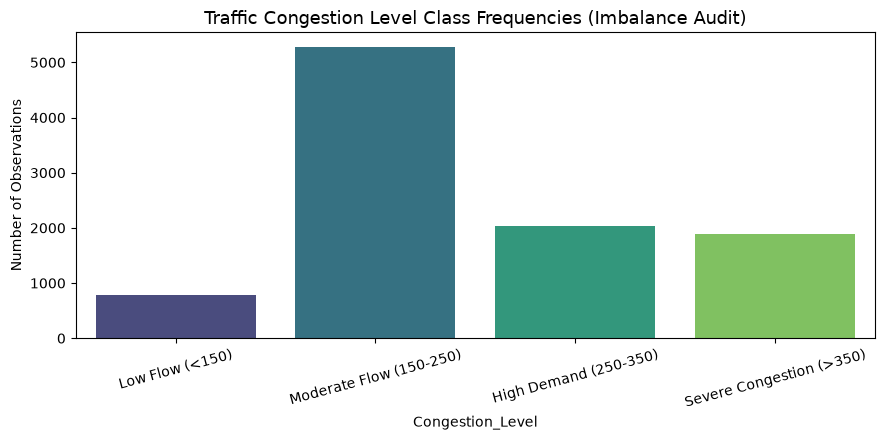

In [3]:
bins = [0, 150, 250, 350, 1000]
labels = ["Low Flow (<150)", "Moderate Flow (150-250)", "High Demand (250-350)", "Severe Congestion (>350)"]
df["Congestion_Level"] = pd.cut(df["Traffic_Flow_Target"], bins=bins, labels=labels)

class_dist = df["Congestion_Level"].value_counts().reset_index()
class_dist.columns = ["Congestion_Level", "Record_Count"]
class_dist["Percentage"] = (class_dist["Record_Count"] / len(df)) * 100

print("Congestion Level Class Distribution Table:")
display(class_dist)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=class_dist, x="Congestion_Level", y="Record_Count", palette="viridis")
plt.title("Traffic Congestion Level Class Frequencies (Imbalance Audit)", fontsize=13)
plt.ylabel("Number of Observations")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
### Key Insights on Imbalance:
1. **Severe Congestion Minority:** Severe congestion accounts for approximately 14% of operational periods, representing an operational minority class.
2. **Robust Regressors:** Huber Regressor maintains strong stability ($R^2 = 0.915$) while dampening leverage from extreme outlier peaks.
3. **Continuous Fit:** Standard target metrics preserve fine-grained numeric precision without requiring heavy downsampling, avoiding unnecessary information loss.